Delivery delays directly damage customer satisfaction and increase support overhead. The goal of this project is to build an optimized, data-leakage-free machine learning pipeline to predict whether a shipment will be delayed (1) or arrive on time (0), and isolate the operational drivers causing supply chain bottlenecks.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_curve, auc

**Opening the csv**

In [ ]:
data=pd.read_csv('shipping data for project.csv')

**Understanding the data**

In [ ]:
data.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [ ]:
data.tail()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0
10998,10999,D,Ship,2,5,155,5,low,F,6,1639,0


In [ ]:
data.shape

(10999, 12)

In [ ]:
data.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,5500.00000,4.054459,2.990545,210.196836,3.567597,13.373216,3634.016729,0.596691
std,3175.28214,1.141490,1.413603,48.063272,1.522860,16.205527,1635.377251,0.490584
min,1.00000,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,2750.50000,3.000000,2.000000,169.000000,3.000000,4.000000,1839.500000,0.000000
50%,5500.00000,4.000000,3.000000,214.000000,3.000000,7.000000,4149.000000,1.000000
75%,8249.50000,5.000000,4.000000,251.000000,4.000000,10.000000,5050.000000,1.000000
max,10999.00000,7.000000,5.000000,310.000000,10.000000,65.000000,7846.000000,1.000000


from the data we see that we have no missing values in the data

In [ ]:
data.nunique()

,0
ID,10999
Warehouse_block,5
Mode_of_Shipment,3
Customer_care_calls,6
Customer_rating,5
Cost_of_the_Product,215
Prior_purchases,8
Product_importance,3
Gender,2
Discount_offered,65


In [ ]:
for col in ['Warehouse_block', 'Mode_of_Shipment', 'Customer_rating']:
    print(f"Unique values in {col}:", data[col].unique())

Unique values in Warehouse_block: ['D' 'F' 'A' 'B' 'C']
Unique values in Mode_of_Shipment: ['Flight' 'Ship' 'Road']
Unique values in Customer_rating: [2 5 3 1 4]


**Checking using chi square and correlation if Gender and ID are neccesary for our analysis or they can be dropped**

ID is a cardinal column which has its values different. When we apply random forest to search for the importance of the parameters, random forest would give the column an unnecesary focus due to its different values thus it is better to remove the column after statistially checking that it is of no use.

In [ ]:
gender_table = pd.crosstab(data['Gender'], data['Reached.on.Time_Y.N'])
print(gender_table)

Reached.on.Time_Y.N     0     1
Gender                         
F                    2249  3296
M                    2187  3267


In [ ]:
chi2_stat, gender_p_val, dof, expected = chi2_contingency(gender_table)
print(gender_p_val)

0.6367032124181522


In [ ]:
id_corr, id_p_val = pointbiserialr(data['ID'], data['Reached.on.Time_Y.N'])
print (id_corr, id_p_val)



-0.41182249113149005 0.0


**Remove the unneccesary columns**

In [ ]:
data_cleaned= data.drop(columns=['ID', 'Gender'])

The reason we preferred removing the ID column and the gender column before moving towards feature selection is ID has a high cardinality and gender clearly cannot contribute to the delay. Remving them on a early stage after individual importance check helps with the computational efficiency and reduces noise in the data which improves the model efficiency.

In [ ]:
data_cleaned.shape

(10999, 10)

**One hot encoding the categorical data**

In [ ]:
importance_map = {"low": 0, "medium": 1, "high": 2}
data_cleaned["Product_importance"] = data_cleaned["Product_importance"].map(
    importance_map
)

In [ ]:
data_encoded = pd.get_dummies(
    data_cleaned,
    columns=["Warehouse_block", "Mode_of_Shipment"],
    drop_first=True,
    dtype=int,
)

In [ ]:
data_encoded.head()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Road,Mode_of_Shipment_Ship
0,4,2,177,3,0,44,1233,1,0,0,1,0,0,0
1,4,5,216,2,0,59,3088,1,0,0,0,1,0,0
2,2,2,183,4,0,48,3374,1,0,0,0,0,0,0
3,3,3,176,4,1,10,1177,1,1,0,0,0,0,0
4,2,2,184,3,1,46,2484,1,0,1,0,0,0,0


**Checking for multicollineaity in our data**

we added a constant for some reason

In [ ]:
X_pre = data_encoded.drop(columns=["Reached.on.Time_Y.N"])
y = data_encoded["Reached.on.Time_Y.N"]

X_pre_vif = add_constant(X_pre)
vif_pre = pd.DataFrame()
vif_pre["Feature"] = X_pre_vif.columns
vif_pre["VIF_Before"] = [variance_inflation_factor(X_pre_vif.values, i) for i in range(len(X_pre_vif.columns))]

print(vif_pre.sort_values(by="VIF_Before", ascending=False).to_string(index=False))

              Feature  VIF_Before
                const   69.972453
    Warehouse_block_F    2.001221
Mode_of_Shipment_Ship    1.673307
Mode_of_Shipment_Road    1.672462
    Warehouse_block_B    1.667817
    Warehouse_block_D    1.667627
    Warehouse_block_C    1.667575
        Weight_in_gms    1.398510
     Discount_offered    1.300124
  Customer_care_calls    1.261131
  Cost_of_the_Product    1.144890
      Prior_purchases    1.074187
   Product_importance    1.017610
      Customer_rating    1.000499


We dont have any serious multicollinearity in our data.

**Feature Engineering**

In [ ]:
data_encoded['Value_Density'] = data_encoded['Cost_of_the_Product'] / data_encoded['Weight_in_gms']
data_encoded['Customer_Friction_Index'] = data_encoded['Customer_care_calls'] / data_encoded['Customer_rating']
data_engineered = data_encoded.drop(columns=['Cost_of_the_Product', 'Weight_in_gms', 'Customer_care_calls', 'Customer_rating'])

**Checking for Outliers**

In [ ]:
final_continuous_features = ['Discount_offered', 'Value_Density', 'Customer_Friction_Index']

for col in final_continuous_features:
    Q1 = data_engineered[col].quantile(0.25)
    Q3 = data_engineered[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = ((data_engineered[col] < lower_bound) | (data_engineered[col] > upper_bound)).sum()
    print(f"Feature '{col}' true outliers detected after ratio compression: {outliers_count}")

Feature 'Discount_offered' true outliers detected after ratio compression: 2209
Feature 'Value_Density' true outliers detected after ratio compression: 595
Feature 'Customer_Friction_Index' true outliers detected after ratio compression: 731


We will not clip the Discount_offered because it is a very big number.

In [ ]:
ratios_to_clip = ['Value_Density', 'Customer_Friction_Index']
for col in ratios_to_clip:
    Q1 = data_engineered[col].quantile(0.25)
    Q3 = data_engineered[col].quantile(0.75)
    IQR = Q3 - Q1
    data_engineered[col] = np.clip(data_engineered[col], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

In [ ]:
data_engineered.shape

(10999, 12)

In [ ]:
X = data_engineered.drop(columns=["Reached.on.Time_Y.N"])
y = data_engineered["Reached.on.Time_Y.N"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

**Scaling the data**

We scaled the data after splitting the data so to avoid data leakage

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Avoided using forward or backward feature selection since we have a column that has 2209 outliers and we cannot clip them.

**Using Random Forest and Lasso Regression for feature extraction**

In [ ]:
lasso_model_final = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
lasso_model_final.fit(X_train_scaled, y_train)

lasso_preds = lasso_model_final.predict(X_test_scaled)
lasso_probs = lasso_model_final.predict_proba(X_test_scaled)[:, 1]
# we used lasso_probs so that we can caluculate the ROC-AUC using soft probabilities

print(f"Lasso Overall Accuracy: {accuracy_score(y_test, lasso_preds):.4f}")
print(f"Lasso ROC-AUC Score:    {roc_auc_score(y_test, lasso_probs):.4f}\n")
print(classification_report(y_test, lasso_preds))

Lasso Overall Accuracy: 0.6223
Lasso ROC-AUC Score:    0.6951

              precision    recall  f1-score   support

           0       0.53      0.55      0.54       887
           1       0.69      0.67      0.68      1313

    accuracy                           0.62      2200
   macro avg       0.61      0.61      0.61      2200
weighted avg       0.62      0.62      0.62      2200



In [ ]:
lasso_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Impact_Score': lasso_model_final.coef_[0]
}).sort_values(by='Impact_Score', ascending=False)

print(lasso_importance_df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

                Feature  Impact_Score
       Discount_offered      1.935872
          Value_Density      0.121919
     Product_importance      0.037282
      Warehouse_block_D      0.023071
      Warehouse_block_F      0.000000
      Warehouse_block_B      0.000000
  Mode_of_Shipment_Ship     -0.006192
  Mode_of_Shipment_Road     -0.010737
      Warehouse_block_C     -0.011142
Customer_Friction_Index     -0.067901
        Prior_purchases     -0.085187


In [ ]:
rf_model_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_final.fit(X_train, y_train)

rf_preds = rf_model_final.predict(X_test)
rf_probs = rf_model_final.predict_proba(X_test)[:, 1]

print(f"Random Forest Overall Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(f"Random Forest ROC-AUC Score:    {roc_auc_score(y_test, rf_probs):.4f}\n")
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_preds))

Random Forest Overall Accuracy: 0.6500
Random Forest ROC-AUC Score:    0.7247

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.64      0.60       887
           1       0.73      0.65      0.69      1313

    accuracy                           0.65      2200
   macro avg       0.64      0.65      0.64      2200
weighted avg       0.66      0.65      0.65      2200



In [ ]:
rf_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'RF_Importance_Score': rf_model_final.feature_importances_
}).sort_values(by='RF_Importance_Score', ascending=False)

print(rf_importance_df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

                Feature  RF_Importance_Score
          Value_Density             0.356212
       Discount_offered             0.290718
Customer_Friction_Index             0.143532
        Prior_purchases             0.079301
     Product_importance             0.037775
  Mode_of_Shipment_Ship             0.020440
      Warehouse_block_F             0.017993
      Warehouse_block_C             0.014072
      Warehouse_block_B             0.013815
  Mode_of_Shipment_Road             0.013305
      Warehouse_block_D             0.012839


**Hyper parameter tuning using grid search cv**

In [ ]:
rf_base = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [6, 8, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Optimal Hyperparameters Identified: {grid_search.best_params_}")
print(f"Peak Cross-Validated ROC-AUC Score: {grid_search.best_score_:.4f}\n")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Optimal Hyperparameters Identified: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 100}
Peak Cross-Validated ROC-AUC Score: 0.7381



In [ ]:
best_rf_model = grid_search.best_estimator_
tuned_rf_preds = best_rf_model.predict(X_test)
tuned_rf_probs = best_rf_model.predict_proba(X_test)[:, 1]

print(f"Final Tuned RF Accuracy:  {accuracy_score(y_test, tuned_rf_preds):.4f}")
print(f"Final Tuned RF ROC-AUC:    {roc_auc_score(y_test, tuned_rf_probs):.4f}\n")

Final Tuned RF Accuracy:  0.6718
Final Tuned RF ROC-AUC:    0.7416



In [ ]:
print(classification_report(y_test, tuned_rf_preds))

              precision    recall  f1-score   support

           0       0.56      0.87      0.68       887
           1       0.86      0.54      0.66      1313

    accuracy                           0.67      2200
   macro avg       0.71      0.70      0.67      2200
weighted avg       0.74      0.67      0.67      2200



**Optimising logistic regression**

In [ ]:
lasso_cv_model = LogisticRegressionCV(
    Cs=20,
    cv=3,
    penalty='l1',
    solver='liblinear',
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

lasso_cv_model.fit(X_train, y_train)
print(f"Optimal Regularization Strength (Best C): {lasso_cv_model.C_[0]:.6f}")
print(f"Best Cross-Validated Linear ROC-AUC:      {lasso_cv_model.scores_[1].mean(axis=0).max():.4f}\n")

Optimal Regularization Strength (Best C): 3792.690191
Best Cross-Validated Linear ROC-AUC:      0.7031



In [ ]:
tuned_lasso_preds = lasso_cv_model.predict(X_test)
tuned_lasso_probs = lasso_cv_model.predict_proba(X_test)[:, 1]
print(f"Final Tuned Lasso Accuracy:  {accuracy_score(y_test, tuned_lasso_preds):.4f}")
print(f"Final Tuned Lasso ROC-AUC:   {roc_auc_score(y_test, tuned_lasso_probs):.4f}\n")
print(classification_report(y_test, tuned_lasso_preds))

Final Tuned Lasso Accuracy:  0.6200
Final Tuned Lasso ROC-AUC:   0.6953

              precision    recall  f1-score   support

           0       0.53      0.54      0.54       887
           1       0.69      0.67      0.68      1313

    accuracy                           0.62      2200
   macro avg       0.61      0.61      0.61      2200
weighted avg       0.62      0.62      0.62      2200



**Finding the impact of each factor in causing the shipment delay**

1.Discount rates

In [ ]:
data_engineered['Discount_Group'] = np.where(data_engineered['Discount_offered'] > 10, 'High Discount (>10%)', 'Standard Discount (≤10%)')
discount_impact = data_engineered.groupby('Discount_Group')['Reached.on.Time_Y.N'].mean() * 100
print(f"Delay Rate under Standard Discounts: {discount_impact.get('Standard Discount (≤10%)', 0):.2f}%")
print(f"Delay Rate under High Promo Surges:  {discount_impact.get('High Discount (>10%)', 0):.2f}%\n")

Delay Rate under Standard Discounts: 46.89%
Delay Rate under High Promo Surges:  100.00%



2.Value density


In [ ]:
data_engineered['Density_Tier'] = pd.qcut(data_engineered['Value_Density'], q=3, labels=['Low Value Density', 'Mid Value Density', 'High Value Density'])
density_impact = data_engineered.groupby('Density_Tier')['Reached.on.Time_Y.N'].mean() * 100
for tier, rate in density_impact.items():
    print(f"  * {tier}: {rate:.2f}% Delayed")

  * Low Value Density: 41.87% Delayed
  * Mid Value Density: 65.48% Delayed
  * High Value Density: 71.66% Delayed


/tmp/ipykernel_4659/1834697027.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  density_impact = data_engineered.groupby('Density_Tier')['Reached.on.Time_Y.N'].mean() * 100


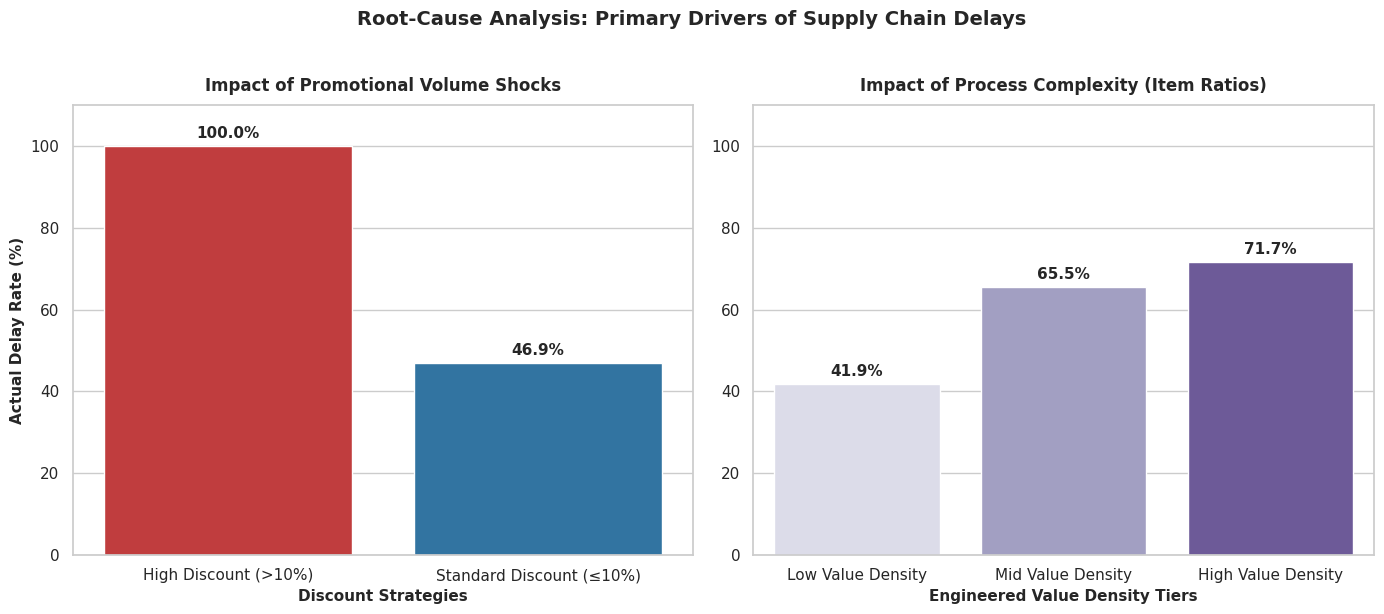

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=100)
sns.set_theme(style="whitegrid")
#For discount impact
sns.barplot(x=discount_impact.index, y=discount_impact.values, ax=axes[0], palette=['#d62728', '#1f77b4'], hue=discount_impact.index, legend=False)
axes[0].set_title('Impact of Promotional Volume Shocks', fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylabel('Actual Delay Rate (%)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Discount Strategies', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 110)
for i, v in enumerate(discount_impact.values):
    axes[0].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=11)

#For density impact
sns.barplot(x=density_impact.index, y=density_impact.values, ax=axes[1],
            palette='Purples', hue=density_impact.index, legend=False)
axes[1].set_title('Impact of Process Complexity (Item Ratios)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Engineered Value Density Tiers', fontsize=11, fontweight='bold')
axes[1].set_ylabel('', )
axes[1].set_ylim(0, 110)
for i, v in enumerate(density_impact.values):
    axes[1].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Root-Cause Analysis: Primary Drivers of Supply Chain Delays', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()


After cleaning the dataset's scale distortions and evaluating the true baseline factors, we discovered that shipping delays are not random operational noise. Instead, they are being driven by two factors, the Discount rates and the cost density of the product.
As the discount rate increases, the volume of the product consumed increases thus creating a block in the delivery ways.
The increase in the Value density causes increase in delay because of the increasing measures to be taken with the delicate materials like phone. These require high risk consignments, and asset protection protocol.